In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("netflix_titles.csv")
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
data[data["country"] == "Turkey"].head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
21,s22,TV Show,Resurrection: Ertugrul,NaN,"Engin Altan Düzyatan, Serdar Gökhan, Hülya Dar...",Turkey,"September 22, 2021",2018,TV-14,5 Seasons,"International TV Shows, TV Action & Adventure,...",When a good deed unwittingly endangers his cla...
703,s704,TV Show,The Gift,NaN,"Beren Saat, Mehmet Günsür, Metin Akdülger, Mel...",Turkey,"June 17, 2021",2021,TV-MA,3 Seasons,"International TV Shows, TV Dramas, TV Mysteries",A painter in Istanbul embarks on a personal jo...
906,s907,Movie,Have You Ever Seen Fireflies? - Theatre Play,Yılmaz Erdoğan,"Demet Akbağ, Zerrin Sümer, Sinan Bengier, Sali...",Turkey,"May 7, 2021",1999,TV-MA,118 min,"Dramas, International Movies",Yılmaz Erdoğan's lauded stage play traces the ...
972,s973,TV Show,Fatma,NaN,"Burcu Biricik, Uğur Yücel, Mehmet Yılmaz Ak, H...",Turkey,"April 27, 2021",2021,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Thrillers","Reeling from tragedy, a nondescript house clea..."
976,s977,Movie,Among Family,Ozan Açıktan,"Engin Günaydın, Demet Evgar, Erdal Özyağcılar,...",Turkey,"April 23, 2021",2017,TV-14,127 min,"Comedies, International Movies","Amid a marital crisis, Fikret befriends songst..."


In [5]:
cast_data = data[data["country"] == "Turkey"]["cast"]
cast_list = cast_data.str.split(r'\s*,\s*')
cast_list

21      [Engin Altan Düzyatan, Serdar Gökhan, Hülya Da...
703     [Beren Saat, Mehmet Günsür, Metin Akdülger, Me...
906     [Demet Akbağ, Zerrin Sümer, Sinan Bengier, Sal...
972     [Burcu Biricik, Uğur Yücel, Mehmet Yılmaz Ak, ...
976     [Engin Günaydın, Demet Evgar, Erdal Özyağcılar...
                              ...                        
7980    [Tolga Çevik, Köksal Engür, Pelin Körmükçü, To...
8682    [Yılmaz Erdoğan, Tarık Akan, Altan Erkekli, Ce...
8720    [Settar Tanrıöğen, Uraz Kaygılaroğlu, Berna Ko...
8749    [Şükrü Özyıldız, Aslı Enver, Şenay Gürler, Baş...
8796    [Gökhan Atalay, Payidar Tüfekçioglu, Baran Akb...
Name: cast, Length: 105, dtype: object

In [6]:
exploded_data = cast_list.explode()

result = exploded_data.value_counts().reset_index()

result.columns = ["name", "appear"]

top10 = result.head(10)
top10

,name,appear
0,Demet Akbağ,13
1,Cezmi Baskın,10
2,Cengiz Bozkurt,8
3,Salih Kalyon,8
4,Büşra Pekin,7
5,Fatih Artman,7
6,Ata Demirer,7
7,Yılmaz Erdoğan,7
8,Erdal Tosun,6
9,Cem Yılmaz,6


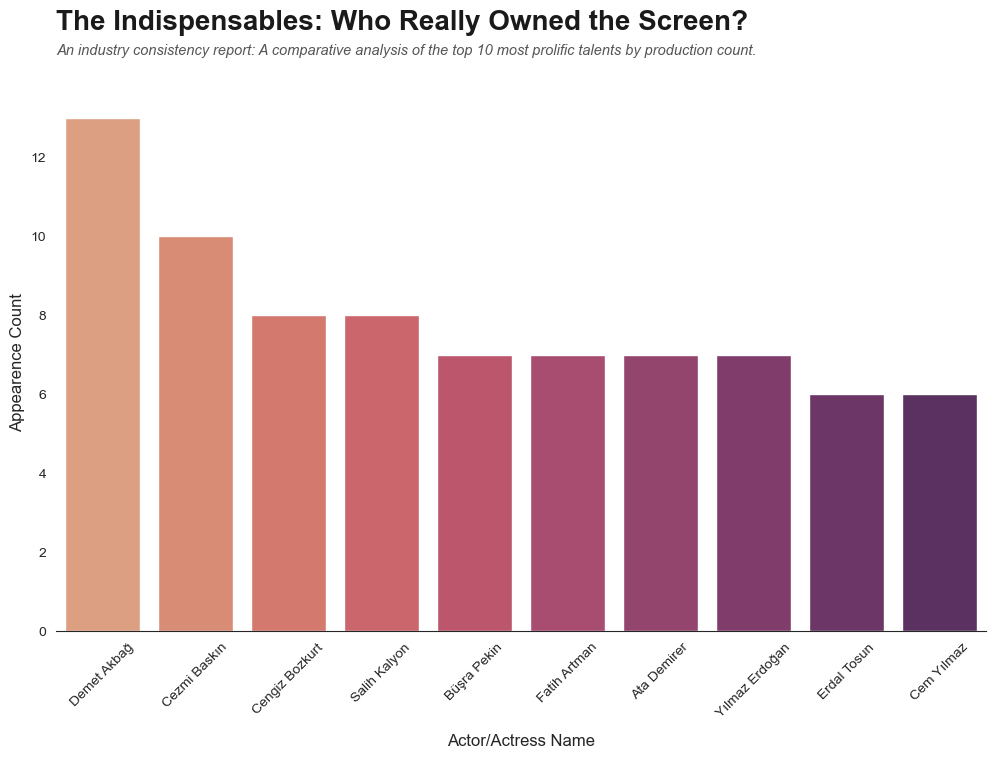

In [7]:
plt.figure(figsize=(12, 7), dpi=100)
sns.set_style("white")

ax = sns.barplot(data=top10, x="name", y="appear", palette="flare")

plt.title("The Indispensables: Who Really Owned the Screen?", 
          fontsize=20, fontweight='bold', pad=45, loc='left', color='#1a1a1a')

ax.text(x=0, y=1.07, 
        s="An industry consistency report: A comparative analysis of the top 10 most prolific talents by production count.", 
        fontsize=10.5, color='#555555', style='italic', transform=ax.transAxes)

sns.despine(left=True, bottom=False)
plt.xlabel("Actor/Actress Name", fontsize=12, labelpad=10)
plt.ylabel("Appearence Count", fontsize=12)
plt.xticks(rotation=45)

plt.show()